In [1]:
!pip install ultralytics
!pip install kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.0 MB/s eta 0:00:00


In [2]:
mkdir -p ~/.kaggle && echo KGAT_d7d747cb3d665c12625a97bfab6a3edf > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [3]:
!kaggle datasets download -d banuprasadb/visdrone-dataset
!unzip visdrone-dataset.zip -d /content/visdrone

Streaming output truncated to the last 5000 lines.
  inflating: /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000236.txt  
  inflating: /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000237.txt  
  inflating: /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000238.txt  
  inflating: /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000239.txt  
  inflating: /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000240.txt  
  inflating: /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000241.txt  
  inflating: /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000242.txt  
  inflating: /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000243.txt  
  inflating: /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951

In [5]:
import os
# VisDrone has these folders:
# images/train, images/val, images/test
# annotations/ (text files per image)
print(os.listdir('/content/visdrone'))

['VisDrone_Dataset']


In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def visualize_sample(img_path, ann_path):
    img = cv2.imread(img_path)

    # Check if image was loaded successfully
    if img is None:
        print(f"Error: Could not load image from {img_path}")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get image dimensions
    print(img.shape)
    img_h, img_w, _ = img.shape

    try:
        with open(ann_path, 'r') as f:

            for line in f.readlines():

                parts = line.strip().split()

                # Expected YOLO format:
                # class_id x_center y_center width height
                if len(parts) == 5:

                    class_id = int(parts[0])

                    x_center_norm, y_center_norm, bbox_width_norm, bbox_height_norm = map(float, parts[1:])

                    # Convert normalized coordinates to pixel coordinates
                    x_min = int((x_center_norm - bbox_width_norm / 2) * img_w)
                    y_min = int((y_center_norm - bbox_height_norm / 2) * img_h)

                    bbox_pixel_width = int(bbox_width_norm * img_w)
                    bbox_pixel_height = int(bbox_height_norm * img_h)

                    # Bottom-right corner
                    x_max = x_min + bbox_pixel_width
                    y_max = y_min + bbox_pixel_height

                    # Draw bounding box
                    cv2.rectangle(
                        img,
                        (x_min, y_min),
                        (x_max, y_max),
                        (0, 255, 0),
                        2
                    )

                    # Display class ID above rectangle
                    cv2.putText(
                        img,
                        f"Class: {class_id}",
                        (x_min, y_min - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6,
                        (255, 0, 0),
                        2
                    )

                else:
                    print(f"Warning: Skipping malformed line in {ann_path}: {line.strip()}")

    except FileNotFoundError:
        print(f"Error: Annotation file not found at {ann_path}")
        return

    except Exception as e:
        print(f"An unexpected error occurred while processing {ann_path}: {e}")
        return

    plt.imshow(img)
    plt.axis('off')
    plt.show()

(540, 960, 3)


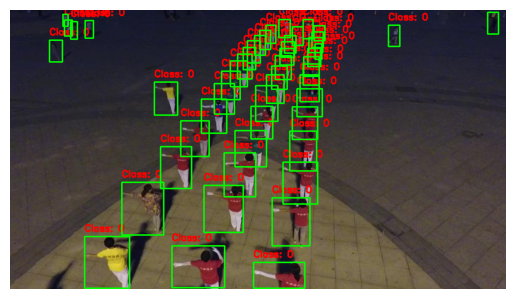

In [7]:
img_path = '/content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/images/0000036_03591_d_0000048.jpg'
ann_path = '/content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/labels/0000036_03591_d_0000048.txt'

# Call the visualization function with the corrected annotation path
visualize_sample(img_path, ann_path)

(540, 960, 3)


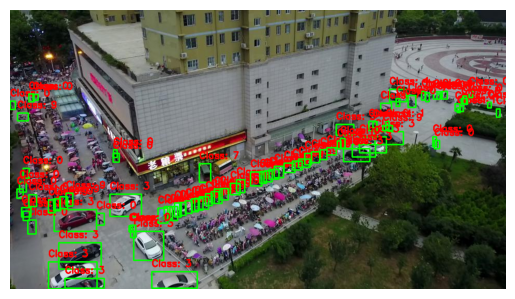

In [8]:
img_path = '/content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/images/0000002_00448_d_0000015.jpg'
ann_path = '/content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/labels/0000002_00448_d_0000015.txt'

# Call the visualization function with the corrected annotation path
visualize_sample(img_path, ann_path)

(540, 960, 3)


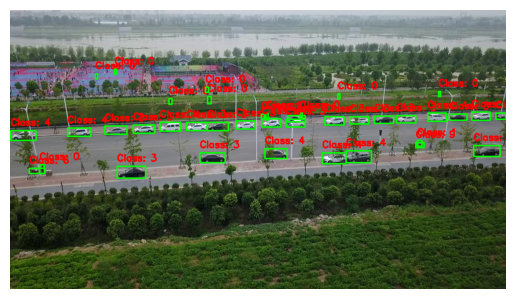

In [9]:
img_path = '/content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/images/0000003_00231_d_0000016.jpg'
ann_path = '/content/visdrone/VisDrone_Dataset/VisDrone2019-DET-train/labels/0000003_00231_d_0000016.txt'

# Call the visualization function with the corrected annotation path
visualize_sample(img_path, ann_path)

In [14]:
import yaml
import os
from ultralytics import YOLO

# Path to the visdrone.yaml file
yaml_path = '/content/visdrone/VisDrone_Dataset/visdrone.yaml'

# Load the existing YAML file
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

# Update the 'path' key in the YAML to the correct absolute root of your dataset.
# The dataset root is '/content/visdrone/VisDrone_Dataset/', which contains
# 'VisDrone2019-DET-train', 'VisDrone2019-DET-val', etc.
data_yaml['path'] = '/content/visdrone/VisDrone_Dataset'

# Ensure the 'train', 'val', and 'test' keys (if they exist) are relative to this 'path'.
# For example, if your original yaml had `train: images/train`, with the new `path` it will look for
# `/content/visdrone/VisDrone_Dataset/images/train`. If it had `train: VisDrone2019-DET-train/images` it will be correct.
# We assume the relative paths for train/val/test within the YAML are correct once the base 'path' is set.

# Write the updated YAML back to the file
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(f"Updated {yaml_path} with correct 'path' key to: {data_yaml['path']}")

Updated /content/visdrone/VisDrone_Dataset/visdrone.yaml with correct 'path' key to: /content/visdrone/VisDrone_Dataset


In [11]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
model = YOLO('yolov8n.pt')  # 'n' = nano, fastest for Colab

model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=4,
    project='/content/drive/MyDrive/yolo_runs',
    name='visdrone_exp'
)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/visdrone/VisDrone_Dataset/visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=visdrone_exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79788b193440>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [9]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load trained model
model = YOLO('/content/drive/MyDrive/yolo_runs/visdrone_exp/weights/best.pt')

# Only detect these classes
CLASS_NAMES = {
    0: "human",   # pedestrian
    3: "car"
}

# Colors
CLASS_COLORS = {
    0: (0, 255, 0),   # Green for humans
    3: (255, 0, 0)    # Blue for cars
}

def detect_humans_and_cars(image_path, show=True):

    # Run inference
    results = model(image_path)[0]

    # Copy original image
    img = results.orig_img.copy()

    # Human counter
    human_count = 0

    # Loop through detections
    for box in results.boxes:

        cls = int(box.cls[0])
        conf = float(box.conf[0])

        # Skip unwanted classes
        if cls not in CLASS_NAMES:
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        class_name = CLASS_NAMES[cls]
        color = CLASS_COLORS[cls]

        # Count only humans
        if cls == 0:
            human_count += 1

        # Label
        label = f"{class_name} {conf:.2f}"

        # Draw rectangle
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        # Draw class label
        cv2.putText(
            img,
            label,
            (x1, y1 - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )

    # Show human count on image
    cv2.putText(
        img,
        f"Human Count: {human_count}",
        (10, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    # Display image
    if show:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(14, 10))
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title("Human and Car Detection")
        plt.show()

    return human_count


image 1/1 /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-val/images/0000001_05999_d_0000011.jpg: 384x640 23 pedestrians, 60 cars, 3 vans, 1 motor, 8.7ms
Speed: 2.8ms preprocess, 8.7ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


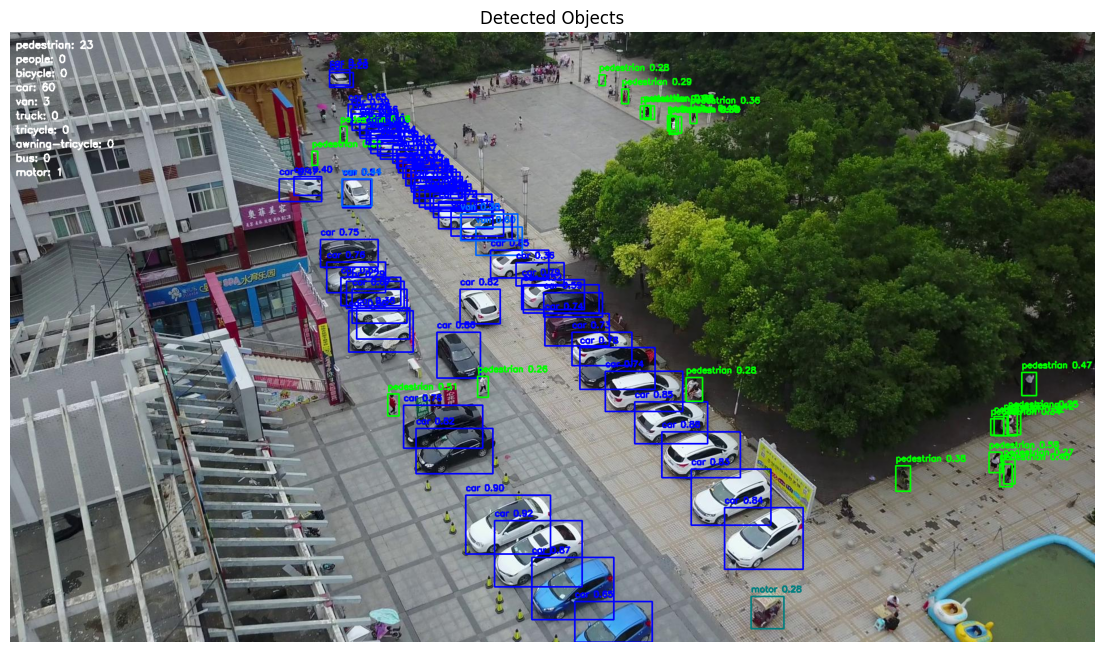

In [10]:
detect_and_count('/content/visdrone/VisDrone_Dataset/VisDrone2019-DET-val/images/0000001_05999_d_0000011.jpg')


image 1/1 /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-val/images/0000001_07999_d_0000012.jpg: 384x640 13 pedestrians, 8 cars, 2 vans, 4 motors, 8.7ms
Speed: 3.0ms preprocess, 8.7ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


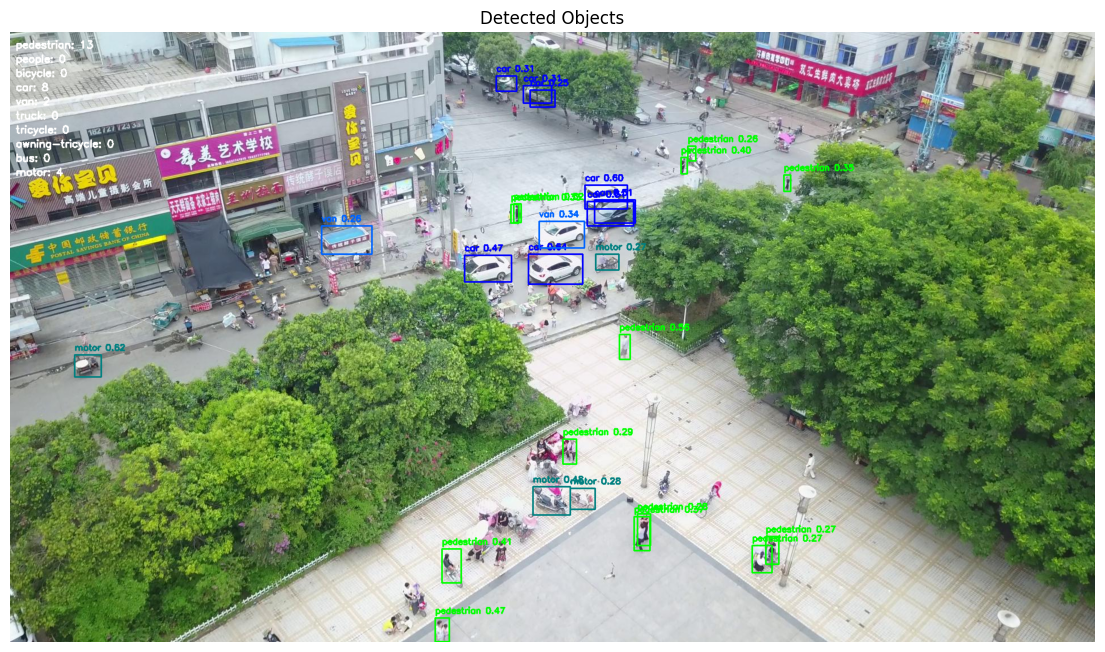

In [11]:
detect_and_count('/content/visdrone/VisDrone_Dataset/VisDrone2019-DET-val/images/0000001_07999_d_0000012.jpg')


image 1/1 /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-val/images/0000023_00000_d_0000008.jpg: 384x640 20 pedestrians, 4 peoples, 1 car, 2 motors, 15.6ms
Speed: 2.8ms preprocess, 15.6ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


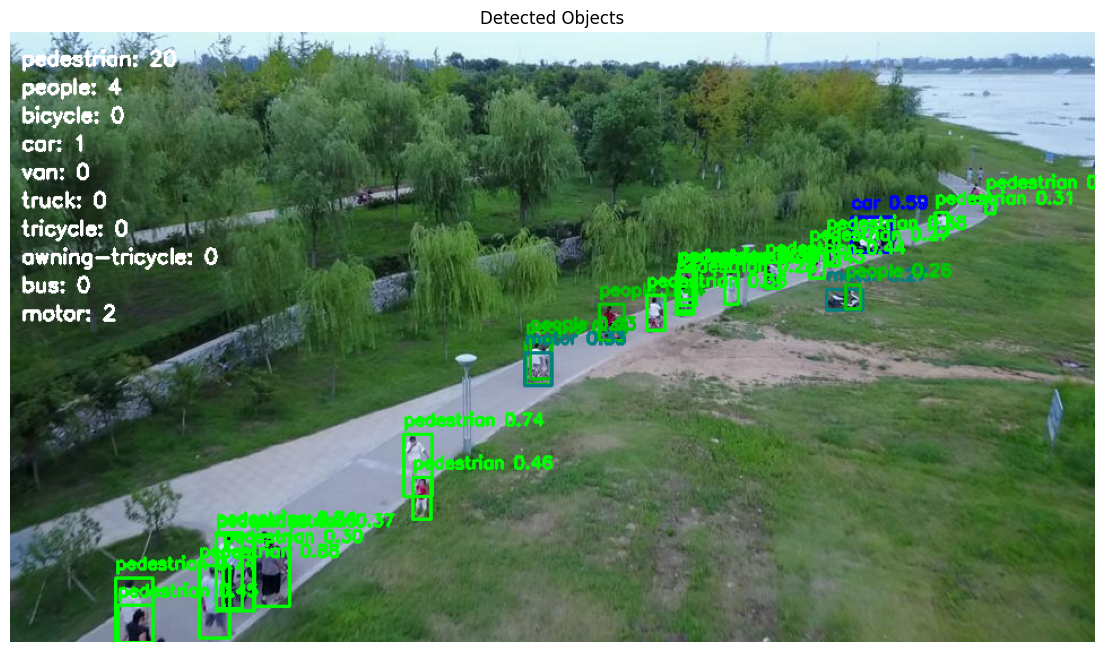

In [12]:
detect_and_count('/content/visdrone/VisDrone_Dataset/VisDrone2019-DET-val/images/0000023_00000_d_0000008.jpg')

In [15]:
# Get mAP, precision, recall automatically
metrics = model.val(data='/content/visdrone/VisDrone_Dataset/visdrone.yaml')
print(f"mAP50: {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.p.mean():.3f}")
print(f"Recall: {metrics.box.r.mean():.3f}")

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2611.4±1166.2 MB/s, size: 127.7 KB)
val: Scanning /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-val/labels... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 1.4Kit/s 0.4s
val: New cache created: /content/visdrone/VisDrone_Dataset/VisDrone2019-DET-val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 2.6it/s 13.7s
                   all        548      38759      0.399      0.304      0.271      0.151
            pedestrian        520       8844      0.407      0.322      0.282      0.112
                people        482       5125       0.45      0.225       0.21     0.0675
               bicycle        364       1287       0.21     0.0723     0.0492     0.0159
                   car        515      14064       0.55      0.748      0.709      0.458
       